# HW2 Hyperparameter Sweep (InvertedPendulum)

Runs come from the grid in `src/scripts/modal_run.py`:
`n_layers` x `layer_size` x `batch_size` x `learning_rate`.

We score every run by **how many env steps (`Train_EnvstepsSoFar`) it needs to first reach
`Eval_AverageReturn >= 1000`**. Fewer steps is better. Runs that never reach 1000 are treated
as needing the full training budget (penalised, not dropped).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb

PROJECT = "cs285_hw2"
CACHE_DIR = Path("../wandb_cache")
NAME_PREFIX = "pendulum"        # only the HPO sweep runs
THRESHOLD = 1000                # target Eval_AverageReturn
X_METRIC = "Train_EnvstepsSoFar"
Y_METRIC = "Eval_AverageReturn"
HP_KEYS = ["n_layers", "layer_size", "batch_size", "learning_rate"]

# The current sweep grid (mirror of src/scripts/modal_run.py). Used to drop
# stale pendulum runs from earlier sweep versions that share the project.
GRID = {
    "n_layers": [2, 4, 8],
    "layer_size": [64, 128, 256],
    "batch_size": [1000, 2000, 4000],
    "learning_rate": [1e-2, 3.16e-3, 1e-3, 3.16e-4, 1e-4],
}

In [2]:
def download_runs(project, cache_dir, metrics):
    """Download each run's config + history, keyed by run id.

    Finished runs are cached as JSON so repeat calls are fast. Runs that are
    still running are always refetched (the sweep is live), so the notebook
    picks up their latest history every time it is re-run.
    """
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    api = wandb.Api()
    run_data = {}
    for run in api.runs(project):
        cache_path = cache_dir / f"{run.id}_hpo.json"
        payload = None
        if cache_path.exists():
            with open(cache_path) as f:
                cached = json.load(f)
            if cached.get("state") == "finished":  # trust only completed runs
                payload = cached
        if payload is None:
            rows = list(run.scan_history())
            full = pd.DataFrame(rows)
            cols = [c for c in metrics if c in full.columns]
            data = full[cols].to_dict(orient="list") if cols else {}
            payload = {"config": dict(run.config), "state": run.state, "data": data}
            if run.state == "finished":
                with open(cache_path, "w") as f:
                    json.dump(payload, f)
        run_data[run.id] = payload
    return run_data

In [3]:
def steps_to_threshold(data, threshold, x=X_METRIC, y=Y_METRIC):
    """First x-value where y >= threshold; NaN if never reached."""
    df = pd.DataFrame(data)
    if x not in df.columns or y not in df.columns:
        return np.nan
    df = df.dropna(subset=[x, y]).sort_values(x)
    hit = df[df[y] >= threshold]
    return float(hit[x].iloc[0]) if len(hit) else np.nan


def in_grid(cfg, grid):
    """True if every hyperparameter in cfg matches a value in the sweep grid."""
    return all(cfg.get(k) in vals for k, vals in grid.items())


def build_hpo_table(run_data, threshold, name_prefix, hp_keys, grid):
    """One row per sweep run with its hyperparameters and steps-to-threshold."""
    rows = []
    for payload in run_data.values():
        cfg = payload.get("config", {})
        if not str(cfg.get("exp_name", "")).startswith(name_prefix):
            continue
        if not in_grid(cfg, grid):  # skip stale runs from older sweep versions
            continue
        row = {k: cfg.get(k) for k in hp_keys}
        row["exp_name"] = cfg.get("exp_name", "")
        row["steps_to_threshold"] = steps_to_threshold(payload.get("data", {}), threshold)
        rows.append(row)
    return pd.DataFrame(rows)

In [4]:
run_data = download_runs(
    PROJECT,
    CACHE_DIR,
    metrics=[X_METRIC, Y_METRIC],
)

hpo = build_hpo_table(run_data, THRESHOLD, NAME_PREFIX, HP_KEYS, GRID)
print(f"{len(hpo)} sweep runs")

# Budget = the largest env-step count any sweep run logged; used to penalise runs
# that never reached the threshold so they still factor into the averages below.
BUDGET = float(np.nanmax([
    pd.DataFrame(p.get("data", {})).get(X_METRIC, pd.Series(dtype=float)).max()
    for p in run_data.values()
    if str(p.get("config", {}).get("exp_name", "")).startswith(NAME_PREFIX)
    and in_grid(p.get("config", {}), GRID)
]))
hpo["steps_filled"] = hpo["steps_to_threshold"].fillna(BUDGET)
n_reached = hpo["steps_to_threshold"].notna().sum()
print(f"{n_reached}/{len(hpo)} runs reached Eval_AverageReturn >= {THRESHOLD}; budget = {BUDGET:.0f} steps")

wandb: Currently logged in as: jasonkrone to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


97 sweep runs
2/97 runs reached Eval_AverageReturn >= 1000; budget = 104561 steps


## 1. Ranking: fewest env steps to reach `Eval_AverageReturn = 1000`

Runs that never reached 1000 sink to the bottom (`NaN`).

In [5]:
ranked = (
    hpo.sort_values("steps_to_threshold", na_position="last")
    .reset_index(drop=True)
)
ranked[["exp_name", *HP_KEYS, "steps_to_threshold"]]

,exp_name,n_layers,layer_size,batch_size,learning_rate,steps_to_threshold
0,pendulum_nl2_ls64_bs1000_lr1e-2_na,2,64,1000,0.010000,60606.0
1,pendulum_nl2_ls64_bs2000_lr1e-2_na,2,64,2000,0.010000,104561.0
2,pendulum_nl2_ls64_bs1000_lr3.16e-3_na,2,64,1000,0.003160,NaN
3,pendulum_nl2_ls64_bs1000_lr1e-3_na,2,64,1000,0.001000,NaN
4,pendulum_nl2_ls64_bs1000_lr3.16e-4_na,2,64,1000,0.000316,NaN
...,...,...,...,...,...,...
92,pendulum_nl8_ls256_bs2000_lr1e-4_na,8,256,2000,0.000100,NaN
93,pendulum_nl8_ls256_bs4000_lr1e-2_na,8,256,4000,0.010000,NaN
94,pendulum_nl8_ls256_bs4000_lr3.16e-3_na,8,256,4000,0.003160,NaN
95,pendulum_nl8_ls256_bs4000_lr1e-3_na,8,256,4000,0.001000,NaN


## 2. Which `n_layers` x `layer_size` performs best?

Averaged over all batch sizes and learning rates. Darker / lower = fewer steps = better.

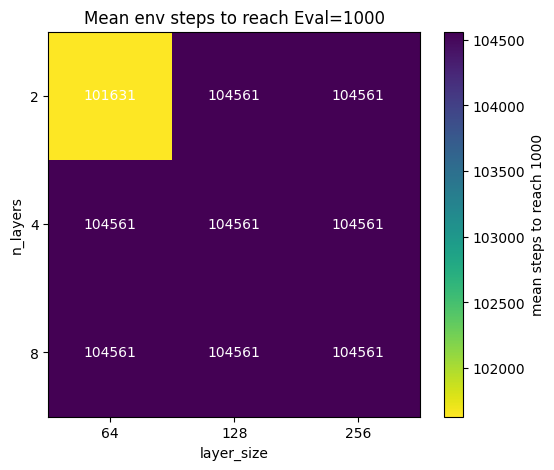

Best: n_layers=2, layer_size=64 (101631 steps)


In [6]:
def heatmap_mean(df, index, columns, value="steps_filled", title=""):
    """Heatmap of mean(value) over the index x columns grid."""
    piv = df.pivot_table(index=index, columns=columns, values=value, aggfunc="mean")
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(piv.values, cmap="viridis_r", aspect="auto")
    ax.set_xticks(range(len(piv.columns)), piv.columns)
    ax.set_yticks(range(len(piv.index)), piv.index)
    ax.set_xlabel(columns)
    ax.set_ylabel(index)
    ax.set_title(title)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f"{piv.values[i, j]:.0f}", ha="center", va="center", color="w")
    fig.colorbar(im, ax=ax, label="mean steps to reach 1000")
    plt.show()
    return piv


piv = heatmap_mean(hpo, index="n_layers", columns="layer_size",
                   title="Mean env steps to reach Eval=1000")
best = piv.stack().idxmin()
print(f"Best: n_layers={best[0]}, layer_size={best[1]} ({piv.stack().min():.0f} steps)")

## 3. On average, do larger batch sizes perform better?

Averaged over all `n_layers`, `layer_size`, and learning rates.

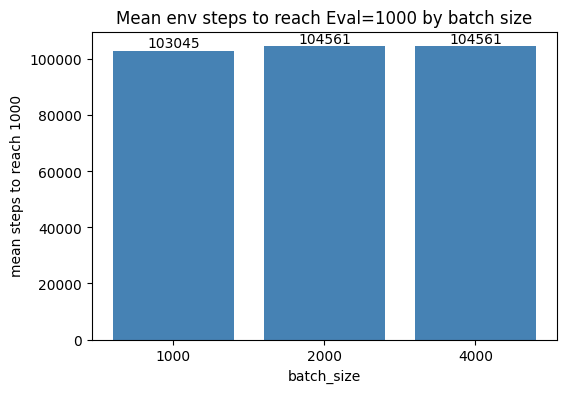

Best batch size: 1000 (103045 steps)


In [7]:
def bar_mean(df, by, value="steps_filled", title="", xlabel=""):
    """Bar chart of mean(value) grouped by a single column."""
    g = df.groupby(by)[value].mean()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar([str(x) for x in g.index], g.values, color="steelblue")
    ax.set_xlabel(xlabel or by)
    ax.set_ylabel("mean steps to reach 1000")
    ax.set_title(title)
    for x, v in zip([str(x) for x in g.index], g.values):
        ax.text(x, v, f"{v:.0f}", ha="center", va="bottom")
    plt.show()
    return g


g = bar_mean(hpo, by="batch_size", title="Mean env steps to reach Eval=1000 by batch size")
print(f"Best batch size: {g.idxmin()} ({g.min():.0f} steps)")

## 4. What's the best learning rate for each batch size?

Averaged over all `n_layers` and `layer_size`. The circled point is the best lr per batch size.

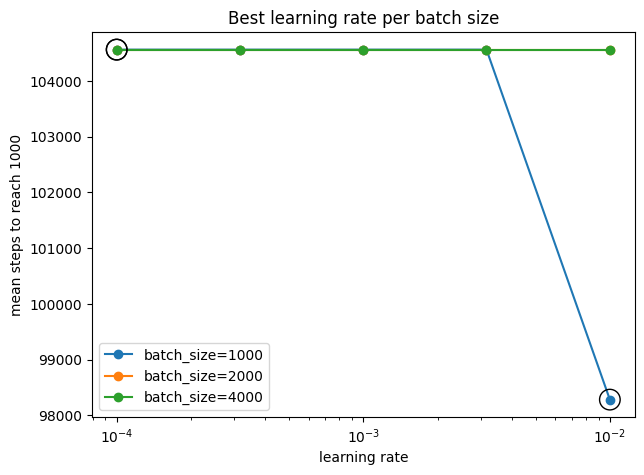

,batch_size,best_lr,mean_steps
0,1000,0.0100,98281.714286
1,2000,0.0001,104561.000000
2,4000,0.0001,104561.000000


In [8]:
def lr_per_batch(df, value="steps_filled"):
    """Plot mean(value) vs learning_rate, one line per batch_size; circle the best lr."""
    fig, ax = plt.subplots(figsize=(7, 5))
    best_rows = []
    for bs, sub in df.groupby("batch_size"):
        s = sub.groupby("learning_rate")[value].mean().sort_index()
        ax.plot(s.index, s.values, marker="o", label=f"batch_size={bs}")
        best_lr = s.idxmin()
        ax.scatter([best_lr], [s[best_lr]], s=220, facecolors="none", edgecolors="k", zorder=5)
        best_rows.append({"batch_size": bs, "best_lr": best_lr, "mean_steps": s[best_lr]})
    ax.set_xscale("log")
    ax.set_xlabel("learning rate")
    ax.set_ylabel("mean steps to reach 1000")
    ax.set_title("Best learning rate per batch size")
    ax.legend()
    plt.show()
    return pd.DataFrame(best_rows).sort_values("batch_size").reset_index(drop=True)


lr_per_batch(hpo)